In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# Load dataset
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to range 0-1
x_train, x_test = x_train / 255.0, x_test / 255.0


In [8]:
# Define the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Flatten input image (28x28) to a vector
    keras.layers.Dense(128, activation='relu'),  # Fully connected hidden layer with 128 neurons
    keras.layers.Dense(64, activation='relu'),  # Fully connected hidden layer with 128 neurons
    keras.layers.Dense(32, activation='relu'),  # Fully connected hidden layer with 128 neurons
    keras.layers.Dense(16, activation='relu'),  # Fully connected hidden layer with 128 neurons
    keras.layers.Dense(10, activation='softmax')  # Output layer (10 classes for digits 0-9)
])


In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [10]:
model.fit(x_train, y_train, epochs=25)


Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8052 - loss: 0.6354
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9646 - loss: 0.1217
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9732 - loss: 0.0876
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9820 - loss: 0.0584
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9852 - loss: 0.0487
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0428
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9887 - loss: 0.0337
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9906 - loss: 0.0286
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9924 - loss: 0.0232
Epoch 10/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9924 - loss: 0.0240
Epoch 11/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9949 - loss: 0.0164
Epoch 12/25
1875/1875 ━━━━━━━

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9755 - loss: 0.1503
Test Accuracy: 97.96%


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


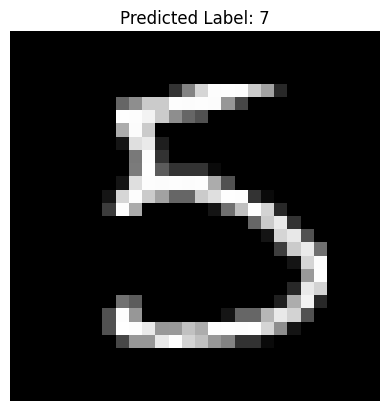

In [12]:
predictions = model.predict(x_test)

# Show the first test image and its predicted label
plt.imshow(x_test[15], cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()


In [13]:
# Define a CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Conv Layer 1
    keras.layers.MaxPooling2D((2, 2)),  # Pooling Layer 1

    keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Conv Layer 2
    keras.layers.MaxPooling2D((2, 2)),  # Pooling Layer 2

    keras.layers.Flatten(),  # Flatten Feature Maps
    keras.layers.Dense(128, activation='relu'),  # Fully Connected Layer
    keras.layers.Dense(10, activation='softmax')  # Output Layer (10 classes)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [15]:
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9088 - loss: 0.3000 - val_accuracy: 0.9864 - val_loss: 0.0442
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9857 - loss: 0.0463 - val_accuracy: 0.9858 - val_loss: 0.0473
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9898 - loss: 0.0327 - val_accuracy: 0.9893 - val_loss: 0.0315
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9939 - loss: 0.0195 - val_accuracy: 0.9900 - val_loss: 0.0295
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9953 - loss: 0.0143 - val_accuracy: 0.9916 - val_loss: 0.0308


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


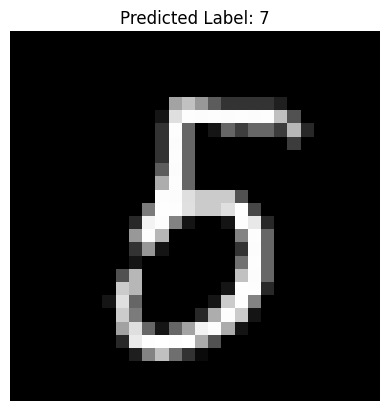

In [16]:
predictions = model.predict(x_test)

# Show the first test image and its predicted label
plt.imshow(x_test[45].reshape(28, 28), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()


In [17]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten


In [18]:
# Load MobileNetV2 as a feature extractor
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Add custom layers for object detection
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
output = Dense(4, activation='sigmoid')(x)  # Output 4 values (x_min, y_min, x_max, y_max)

# Define the new model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])




9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [19]:
# Dummy dataset (Replace this with actual dataset like Pascal VOC or COCO)
X_train = np.random.rand(100, 224, 224, 3)  # 100 random images
y_train = np.random.rand(100, 4)  # 100 bounding box coordinates (x_min, y_min, x_max, y_max)

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=8)


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 997ms/step - accuracy: 0.2999 - loss: 0.2752
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 997ms/step - accuracy: 0.2365 - loss: 0.3284
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 997ms/step - accuracy: 0.2590 - loss: 0.3172
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2043 - loss: 0.3531
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 995ms/step - accuracy: 0.2637 - loss: 0.3441
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 998ms/step - accuracy: 0.2433 - loss: 0.3262
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 991ms/step - accuracy: 0.3044 - loss: 0.3339
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 990ms/step - accuracy: 0.2414 - loss: 0.3172
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 980ms/step - accuracy: 0.2082 - loss: 0.3344
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3006 - loss: 0.3192
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2755 - loss: 0.3255
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 996ms/s

In [22]:
# Load an image for testing
image_path = "/content/car.JPG"  # Replace with an actual image path
image = cv2.imread(image_path)
image = cv2.resize(image, (224, 224))
image = np.array(image) / 255.0  # Normalize pixel values
image = np.expand_dims(image, axis=0)  # Add batch dimension

# Make a prediction
bbox = model.predict(image)[0]  # Get bounding box coordinates

# Draw bounding box on the image
image = cv2.imread(image_path)
h, w, _ = image.shape
x_min, y_min, x_max, y_max = bbox * np.array([w, h, w, h])  # Scale back to original image size
x_min, y_min, x_max, y_max = int(x_min), int(y_min), int(x_max), int(y_max)
print(x_min, y_min, x_max, y_max)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
0 0 442 185


In [23]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt


In [24]:
# Load IMDB dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

# Pad sequences to make inputs uniform
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
# Define the LSTM model
model = keras.Sequential([
    keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=max_length),  # Word Embedding
    keras.layers.LSTM(64, return_sequences=True),  # LSTM Layer 1
    keras.layers.LSTM(32),  # LSTM Layer 2
    keras.layers.Dense(1, activation='sigmoid')  # Output Layer (Binary Classification)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Show model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Train the model
model.fit(x_train, y_train, epochs=1, batch_size=64, validation_data=(x_test, y_test))


391/391 ━━━━━━━━━━━━━━━━━━━━ 72s 176ms/step - accuracy: 0.6923 - loss: 0.5527 - val_accuracy: 0.8412 - val_loss: 0.4331


In [27]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Predict a sample review
sample_review = x_test[0].reshape(1, -1)  # Take one review for prediction
prediction = model.predict(sample_review)

sentiment = "Positive" if prediction[0] > 0.5 else "Negative"
print(f"Predicted Sentiment: {sentiment}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8437 - loss: 0.4280
Test Accuracy: 84.12%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Predicted Sentiment: Negative


In [28]:
len(x_test)

25000

In [29]:
x_test[58]

array([ 689,    2,    2,   34, 2643,  745,    2,  216,    8,   35,  154,
       1430,    8,    2,  671,   36, 2507,    2,    6,    2,    5, 3854,
         11,  160, 4961,  121, 4618,   16, 2730,   34,    6, 5072, 1652,
          5, 9135,   34, 8737,    4,  604,  892, 4358,    2,   34,    2,
        628,    5,    2, 1868,    2,    5,  659,    4,    2,    7,    4,
          2,  884,  745, 5956, 1675,   37,   47,   77,  581,   11,   14,
       4961,   18, 3264,  153,   36, 2883, 1929,  269,    8,    2,    6,
          2,    8,  721,   98,  145,  344,    2,    9,    6, 1753,    7,
          2,   64,  433,   91,    7,    4, 3233,  306,    8,   30,  398,
         34,    6,  415,   37,   47,   24,    2,    4,    2,  396,   38,
          2,   36,   26, 1037,    4,   65,    9, 4330,    5,  186,   15,
       4618,    9,    4,   64,  543,   11,    4,  182,    4, 1656,  269,
          8,  380,   27, 3495, 1692,   19, 1912,    2,   17,   48,   29,
         71, 3247,    6,  519,    9,   55,  163,   

In [30]:
x_test[0].reshape(1, -1)

array([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           1,  591,  202,   14,   31,    6,  717,   10,   10,    2,    2,
           5,    4,  360,    7,    4, 

In [31]:
# Predict a sample review
sample_review = x_test[1].reshape(1, -1)  # Take one review for prediction
prediction = model.predict(sample_review)

sentiment = "Positive" if prediction > 0.5 else "Negative"
print(f"Predicted Sentiment: {sentiment}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Sentiment: Positive


In [32]:
sample_review

array([[1987,    2,   45,   55,  221,   15,  670, 5304,  526,   14, 1069,
           4,  405,    5, 2438,    7,   27,   85,  108,  131,    4, 5045,
        5304, 3884,  405,    9, 3523,  133,    5,   50,   13,  104,   51,
          66,  166,   14,   22,  157,    9,    4,  530,  239,   34, 8463,
        2801,   45,  407,   31,    7,   41, 3778,  105,   21,   59,  299,
          12,   38,  950,    5, 4521,   15,   45,  629,  488, 2733,  127,
           6,   52,  292,   17,    4, 6936,  185,  132, 1988, 5304, 1799,
         488, 2693,   47,    6,  392,  173,    4,    2, 4378,  270, 2352,
           4, 1500,    7,    4,   65,   55,   73,   11,  346,   14,   20,
           9,    6,  976, 2078,    7, 5293,  861,    2,    5, 4182,   30,
        3127,    2,   56,    4,  841,    5,  990,  692,    8,    4, 1669,
         398,  229,   10,   10,   13, 2822,  670, 5304,   14,    9,   31,
           7,   27,  111,  108,   15, 2033,   19, 7836, 1429,  875,  551,
          14,   22,    9, 1193,   21, 

In [33]:
prediction

array([[0.9866494]], dtype=float32)